# Transfer Learning with Pre-trained Model on Oxford Flowers 102 Dataset

## Data Loading and Preprocessing

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2

# Load Oxford Flowers 102 dataset
dataset, info = tfds.load('oxford_flowers102', with_info=True, as_supervised=True)
train_ds = dataset['train']
test_ds = dataset['test']
val_ds = dataset['validation']

IMG_SIZE = (224, 224)

def preprocess(image, label, preprocess_fn):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_fn(image)
    return image, label

X_train_resnet50 = train_ds.map(lambda x, y: preprocess(x, y, preprocess_resnet50))
X_test_resnet50 = test_ds.map(lambda x, y: preprocess(x, y, preprocess_resnet50))

X_train_vgg16 = train_ds.map(lambda x, y: preprocess(x, y, preprocess_vgg16))
X_test_vgg16 = test_ds.map(lambda x, y: preprocess(x, y, preprocess_vgg16))

X_train_mobilenetv2 = train_ds.map(lambda x, y: preprocess(x, y, preprocess_mobilenetv2))
X_test_mobilenetv2 = test_ds.map(lambda x, y: preprocess(x, y, preprocess_mobilenetv2))


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.Y3ORMQ_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.Y3ORMQ_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


## Model Preparation

### Using ResNet50

In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained ResNet50 model without the top layer
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dense(1024, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)  # 102 classes for Oxford Flowers

model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

model_resnet50.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Using VGG16

In [3]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add new layers
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dense(512, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)  # 102 flower classes

model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

model_vgg16.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###  Using MobileNetV2

In [4]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobilenetv2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add new layers
x = GlobalAveragePooling2D()(base_model_mobilenetv2.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)  # 102 flower classes

model_mobilenetv2 = Model(inputs=base_model_mobilenetv2.input, outputs=predictions)

model_mobilenetv2.compile(optimizer='adam',
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Fine-Tuning and Training

In [5]:
epochs = 3

print(len(model_resnet50.layers))
print(len(model_vgg16.layers))
print(len(model_mobilenetv2.layers))

178
22
157


In [9]:
BATCH_SIZE = 32

# Batch and prefetch datasets
train_resnet50 = X_train_resnet50.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_resnet50 = X_test_resnet50.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_vgg16 = X_train_vgg16.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_vgg16 = X_test_vgg16.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_mobilenetv2 = X_train_mobilenetv2.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_mobilenetv2 = X_test_mobilenetv2.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [10]:
# Fine-tuning ResNet50
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False
for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

# Re-compile after changing trainable layers
model_resnet50.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet50 = model_resnet50.fit(
    train_resnet50,
    epochs=epochs,
    validation_data=test_resnet50
)

# Fine-tuning VGG16
for layer in model_vgg16.layers[:-5]:
    layer.trainable = False
for layer in model_vgg16.layers[-5:]:
    layer.trainable = True

model_vgg16.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg16 = model_vgg16.fit(
    train_vgg16,
    epochs=epochs,
    validation_data=test_vgg16
)

# Fine-tuning MobileNetV2
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False
for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

model_mobilenetv2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenetv2 = model_mobilenetv2.fit(
    train_mobilenetv2,
    epochs=epochs,
    validation_data=test_mobilenetv2
)


Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.2097 - loss: 4.0990 - val_accuracy: 0.1324 - val_loss: 29.3369
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 772ms/step - accuracy: 0.8474 - loss: 0.6237 - val_accuracy: 0.1124 - val_loss: 32.6205
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 707ms/step - accuracy: 0.9513 - loss: 0.1763 - val_accuracy: 0.2678 - val_loss: 11.5547
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.0503 - loss: 8.6648 - val_accuracy: 0.2088 - val_loss: 3.5915
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4310 - loss: 2.4847 - val_accuracy: 0.4511 - val_loss: 2.3152
Epoch 3/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7186 - loss: 1.0710 - val_accuracy: 0.4614 - val_loss: 2.4884
Epoch 1/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.1549 - loss: 4.1387 - val_accuracy: 0.1268 - val_loss: 6.4506
Epoch 2/3
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 412ms/step - accuracy: 0.8538 - loss: 0.6861 - val_accuracy: 0.1251 - val_l

## Model Evalution

In [12]:
# Evaluate models on batched datasets
acc_resnet50 = model_resnet50.evaluate(test_resnet50)[1]
acc_vgg16 = model_vgg16.evaluate(test_vgg16)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(test_mobilenetv2)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')

193/193 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.2641 - loss: 11.5552
193/193 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.4552 - loss: 2.5154
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.0629 - loss: 12.7424
ResNet50 Accuracy: 0.27
VGG16 Accuracy: 0.46
MobileNetV2 Accuracy: 0.06


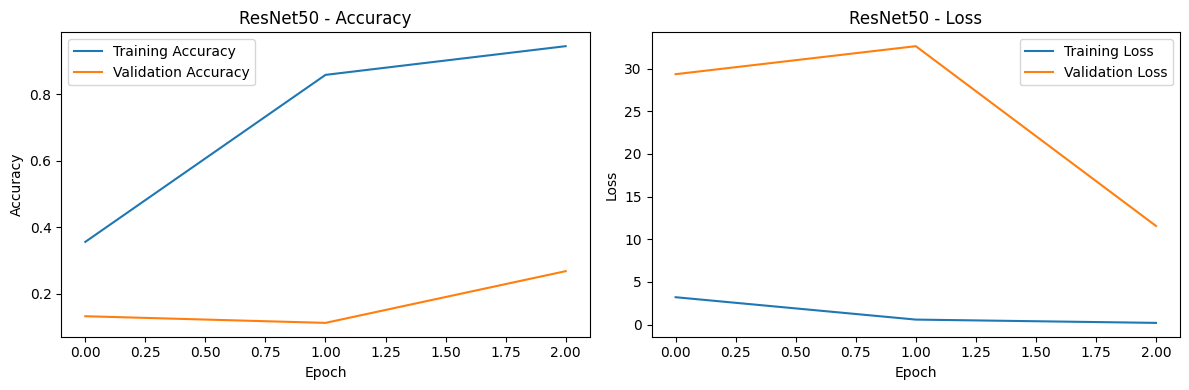

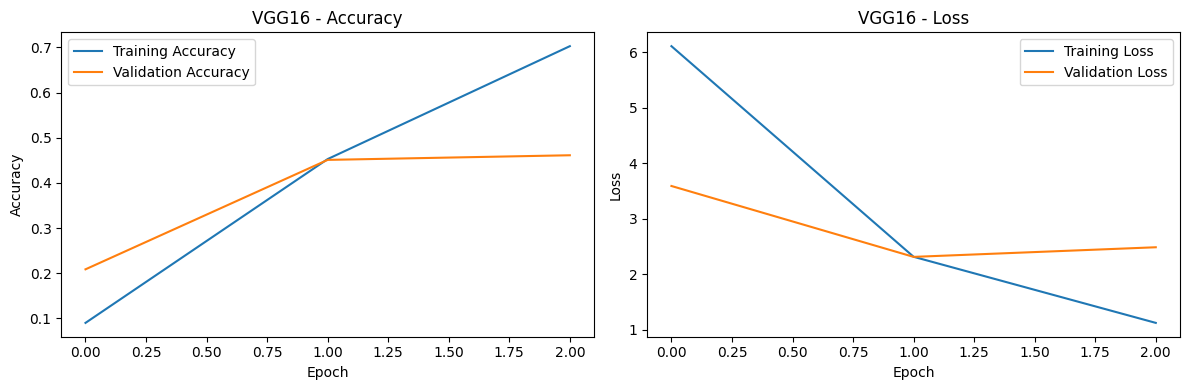

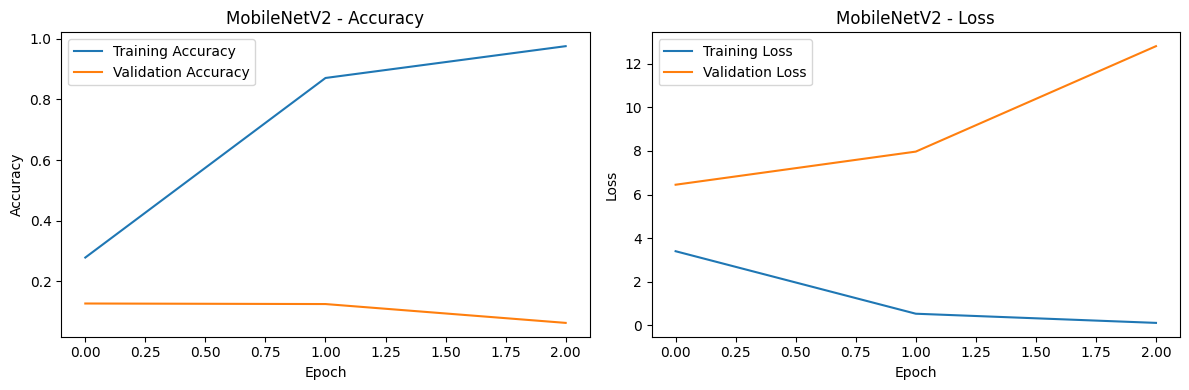

In [13]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot history for each model
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')

In [15]:
# Save the models
model_resnet50.save('resnet50_oxford_flowers102.h5')
model_vgg16.save('vgg16_oxford_flowers102.h5')
model_mobilenetv2.save('mobilenetv2_oxford_flowers102.h5')

## Project Summary





1. **Data Loading and Preprocessing**  
   - Dataset loaded via TensorFlow Datasets (TFDS).  
   - Images resized to 224×224 and preprocessed according to the requirements of each pre-trained model.

2. **Model Preparation**  
   - Pre-trained networks were loaded without their top layers.  
   - Custom fully connected layers were added to adapt the models for 102-class classification.

3. **Fine-tuning and Training**  
   - Most layers were frozen initially; top layers were fine-tuned to the flower dataset.  
   - Models were trained for a few epochs using the Adam optimizer and sparse categorical cross-entropy loss.

4. **Evaluation and Visualization**  
   - Models were evaluated on the test set, and accuracies were reported.  
   - Training history plots (accuracy and loss) were generated to monitor performance.

5. **Model Saving**  
   - Trained models were saved for future inference or deployment.